In [1]:
# Bibliotecas principais e métricas
import binascii
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from utils.utils import create_time_windows

2026-02-06 20:48:11.025291: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-06 20:48:11.071509: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-06 20:48:11.942567: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Previsao de precipitacao para a proxima hora

Este notebook treina um modelo 1D CNN para prever chuva (saida binaria) a partir de series temporais de temperatura, umidade e pressao em ILHEUS. O objetivo e gerar um modelo leve, pronto para uso embarcado (TensorFlow Lite INT8).

## 1. Carregar dados

In [2]:
# Carregar dados
df = pd.read_parquet('../../data/weather_ba.parquet')
df.head()

,precipitacao,pressao,temperatura,umidade,estacao,estado,cidade,datetime
0,0.0,1007.400024,27.200001,77.0,A401,BA,SALVADOR,2000-05-13 00:00:00
1,0.0,1007.400024,27.200001,77.0,A401,BA,SALVADOR,2000-05-13 01:00:00
2,0.0,1007.400024,27.200001,77.0,A401,BA,SALVADOR,2000-05-13 02:00:00
3,0.0,1007.400024,27.200001,77.0,A401,BA,SALVADOR,2000-05-13 03:00:00
4,0.0,1007.400024,27.200001,77.0,A401,BA,SALVADOR,2000-05-13 04:00:00


In [3]:
# Visualizar info do dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4347216 entries, 0 to 4347215
Data columns (total 8 columns):
 #   Column        Dtype         
---  ------        -----         
 0   precipitacao  float32       
 1   pressao       float64       
 2   temperatura   float64       
 3   umidade       float64       
 4   estacao       str           
 5   estado        str           
 6   cidade        str           
 7   datetime      datetime64[us]
dtypes: datetime64[us](1), float32(1), float64(3), str(3)
memory usage: 313.8 MB


## 2. Processar dados

### Tratar dados de precipitação

In [4]:
# Categorizar precipitação
df['precip_cat'] = pd.cut(
    df['precipitacao'],
    bins=[-0.1, 0, np.inf],
    labels=['Sem chuva', 'Chuva'],
    include_lowest=True,
    )

### Selecionar dados de ILHEUS

In [5]:
# Contagem das classes em ILHEUS
df[df['cidade'] == 'ILHEUS']['precip_cat'].value_counts()

precip_cat
Sem chuva    125813
Chuva         13867
Name: count, dtype: int64

In [6]:
# Filtrar dados de ILHEUS
df_ilheus = df[df['cidade'] == 'ILHEUS']

### Dropar colunas desnecessárias

In [7]:
# Selecionar colunas relevantes
df_ilheus = df_ilheus[['temperatura', 'umidade', 'pressao', 'precip_cat']]
df_ilheus.head()

,temperatura,umidade,pressao,precip_cat
97920,25.200001,83.0,1005.700012,Sem chuva
97921,25.100000,84.0,1005.900024,Sem chuva
97922,22.900000,93.0,1005.900024,Sem chuva
97923,22.500000,94.0,1005.400024,Sem chuva
97924,22.299999,94.0,1005.000000,Sem chuva


### Criar coluna de variação de pressão

In [8]:
# Criar features de variação
diff_period = 3
df_ilheus['delta_pressao'] = df_ilheus['pressao'].diff(periods=diff_period)
df_ilheus['delta_temperatura'] = df_ilheus['temperatura'].diff(periods=diff_period)
df_ilheus['delta_umidade'] = df_ilheus['umidade'].diff(periods=diff_period)
for col in ['delta_pressao', 'delta_temperatura', 'delta_umidade']:
    df_ilheus[col] = df_ilheus[col].fillna(0)
df_ilheus.head()

,temperatura,umidade,pressao,precip_cat,delta_pressao,delta_temperatura,delta_umidade
97920,25.200001,83.0,1005.700012,Sem chuva,0.000000,0.000000,0.0
97921,25.100000,84.0,1005.900024,Sem chuva,0.000000,0.000000,0.0
97922,22.900000,93.0,1005.900024,Sem chuva,0.000000,0.000000,0.0
97923,22.500000,94.0,1005.400024,Sem chuva,-0.299988,-2.700001,11.0
97924,22.299999,94.0,1005.000000,Sem chuva,-0.900024,-2.800001,10.0


In [9]:
# Estatísticas das features
df_ilheus.describe()

,temperatura,umidade,pressao,delta_pressao,delta_temperatura,delta_umidade
count,139680.000000,139680.000000,139680.000000,139680.000000,139680.000000,139680.000000
mean,23.731987,83.386107,1004.865060,-0.000039,0.000021,-0.000007
std,3.365982,14.152890,5.948652,1.203082,2.089279,9.281079
min,12.300000,10.000000,963.700012,-19.293349,-13.000000,-46.000000
25%,21.400000,74.000000,1003.233111,-0.899963,-1.200001,-2.000000
50%,23.500000,87.000000,1005.500000,0.007412,-0.299999,0.000000
75%,26.000000,95.000000,1008.299988,1.000000,0.500000,4.000000
max,40.500000,100.000000,1017.200012,11.759985,13.000000,38.000000


### Tratar coluna categorica precip

In [10]:
# Codificação da coluna de precipitação
ordem_precip = ['Sem chuva', 'Chuva']

df_ilheus = df_ilheus.dropna(subset=['precip_cat'])
df_ilheus['precip_cat'] = pd.Categorical(df_ilheus['precip_cat'], categories=ordem_precip, ordered=True)
df_ilheus['target'] = df_ilheus['precip_cat'].cat.codes

if 'precip_cat' in df_ilheus.columns:
    df_ilheus.drop(columns=['precip_cat'], inplace=True)

df_ilheus.head()

,temperatura,umidade,pressao,delta_pressao,delta_temperatura,delta_umidade,target
97920,25.200001,83.0,1005.700012,0.000000,0.000000,0.0,0
97921,25.100000,84.0,1005.900024,0.000000,0.000000,0.0,0
97922,22.900000,93.0,1005.900024,0.000000,0.000000,0.0,0
97923,22.500000,94.0,1005.400024,-0.299988,-2.700001,11.0,0
97924,22.299999,94.0,1005.000000,-0.900024,-2.800001,10.0,0


### Fazer o shift no Target

In [11]:
# Shift do target para prever próxima hora
df_ilheus['target_shifted'] = df_ilheus['target'].shift(-1)
df_ilheus = df_ilheus.dropna(subset=['target_shifted'])
df_ilheus['target_shifted'] = df_ilheus['target_shifted'].astype(int)

df_ilheus.head()

,temperatura,umidade,pressao,delta_pressao,delta_temperatura,delta_umidade,target,target_shifted
97920,25.200001,83.0,1005.700012,0.000000,0.000000,0.0,0,0
97921,25.100000,84.0,1005.900024,0.000000,0.000000,0.0,0,0
97922,22.900000,93.0,1005.900024,0.000000,0.000000,0.0,0,0
97923,22.500000,94.0,1005.400024,-0.299988,-2.700001,11.0,0,0
97924,22.299999,94.0,1005.000000,-0.900024,-2.800001,10.0,0,0


### Normalizar os dados

In [12]:
# Normalizar features
features = ['temperatura', 'umidade', 'pressao', 'delta_pressao', 'delta_temperatura', 'delta_umidade']
scaler = StandardScaler()
df_ilheus[features] = scaler.fit_transform(df_ilheus[features])

print("mean:", scaler.mean_)
print("scale:", scaler.scale_)

df_ilheus.head()

mean: [ 2.37319765e+01  8.33860739e+01  1.00486506e+03 -5.29792270e-05
  3.22167255e-05 -8.59112680e-05]
scale: [ 3.36597984 14.15288448  5.94865175  1.20307008  2.08927441  9.28103259]


,temperatura,umidade,pressao,delta_pressao,delta_temperatura,delta_umidade,target,target_shifted
97920,0.436136,-0.027279,0.140360,0.000044,-0.000015,0.000009,0,0
97921,0.406427,0.043378,0.173983,0.000044,-0.000015,0.000009,0,0
97922,-0.247172,0.679291,0.173983,0.000044,-0.000015,0.000009,0,0
97923,-0.366008,0.749948,0.089930,-0.249308,-1.292330,1.185222,0,0
97924,-0.425427,0.749948,0.022684,-0.748062,-1.340194,1.077476,0,0


### Dividir os dados

In [13]:
# Criar janelas temporais e dividir em treino/teste
window_size = 24

X, y = create_time_windows(df_ilheus, features, 'target_shifted', window_size=window_size, forecast_steps=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

### Balancear dados

In [14]:
# Balanceamento do treino com oversampling
ros = RandomOverSampler(random_state=42)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_train_flat_bal, y_train_bal = ros.fit_resample(X_train_flat, y_train)
X_train_bal = X_train_flat_bal.reshape(-1, X_train.shape[1], X_train.shape[2])
unique, counts = np.unique(y_train, return_counts=True)

print("Proporção original (treino):")
for u, c in zip(unique, counts):
    print(f"Classe {u}: {c} ({c/len(y_train):.2%})")

# Depois do oversampling
unique_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
print("Proporção após oversampling:")
for u, c in zip(unique_bal, counts_bal):
    print(f"Classe {u}: {c} ({c/len(y_train_bal):.2%})")

Proporção original (treino):
Classe 0: 101454 (90.81%)
Classe 1: 10270 (9.19%)
Proporção após oversampling:
Classe 0: 101454 (50.00%)
Classe 1: 101454 (50.00%)


## 3. Arquitetura do Modelo CNN
 
**Resumo das escolhas:**
- **Entrada 3D:** janelas temporais (window_size x features) para capturar padrões ao longo do tempo.
- **Camadas Conv1D:** extraem padrões locais entre horas vizinhas.
- **Regularização:** L2 e Dropout para evitar overfitting.
- **Saída binária:** probabilidade de chuva (0 a 1).

In [15]:
# Definir e compilar modelo CNN
num_features = X.shape[2]

print(f"Num features: {num_features}, Window size: {window_size}")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, num_features)),

    tf.keras.layers.Conv1D(filters=32, kernel_size=2, padding="valid", use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv1D(filters=48, kernel_size=2, padding="same", use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy', metrics=['accuracy',
                                                   tf.keras.metrics.Recall(name='recall')])
model.summary()

Num features: 6, Window size: 24


2026-02-06 20:48:13.952012: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 23, 32)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 23, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 23, 48)         │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 23, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1104)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        35,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,169 (153.00 KB)

 Trainable params: 39,009 (152.38 KB)

 Non-trainable params: 160 (640.00 B)

## 4. Treinamento do Modelo
 
Treinamento do modelo CNN com callbacks para evitar overfitting e ajuste automático da learning rate. O balanceamento é feito via oversampling no conjunto de treino.

In [16]:
# Configurar callbacks para otimização de treinamento
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Se a validacao nao melhorar por 3 epocas...
    restore_best_weights=True,  # ...volta para o melhor momento e para.
    verbose=1
)

callbacks = [lr_scheduler, early_stopping]

history = model.fit(
    X_train_bal,
    y_train_bal,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

2026-02-06 20:48:14.076359: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 93499776 exceeds 10% of free system memory.


Epoch 1/50
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6774 - loss: 0.5678 - recall: 0.4981 - val_accuracy: 0.6227 - val_loss: 0.7041 - val_recall: 0.6227 - learning_rate: 1.0000e-04
Epoch 2/50
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7136 - loss: 0.5264 - recall: 0.5944 - val_accuracy: 0.6417 - val_loss: 0.6854 - val_recall: 0.6417 - learning_rate: 1.0000e-04
Epoch 3/50
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7235 - loss: 0.5138 - recall: 0.6194 - val_accuracy: 0.6807 - val_loss: 0.6533 - val_recall: 0.6807 - learning_rate: 1.0000e-04
Epoch 4/50
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7305 - loss: 0.5065 - recall: 0.6378 - val_accuracy: 0.6694 - val_loss: 0.6636 - val_recall: 0.6694 - learning_rate: 1.0000e-04
Epoch 5/50
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7336 - loss: 0.5013 - recall: 0.6430 - val_accuracy: 0.6730 - val_loss: 0.6560 - val_recall: 0.6730 - learning_rate: 1.0000e-04
Epoch 6/50
2537/2537

## 5. Curvas de Acurácia e Loss
 
Visualização do desempenho do modelo durante o treinamento (acurácia e loss para treino e validação).

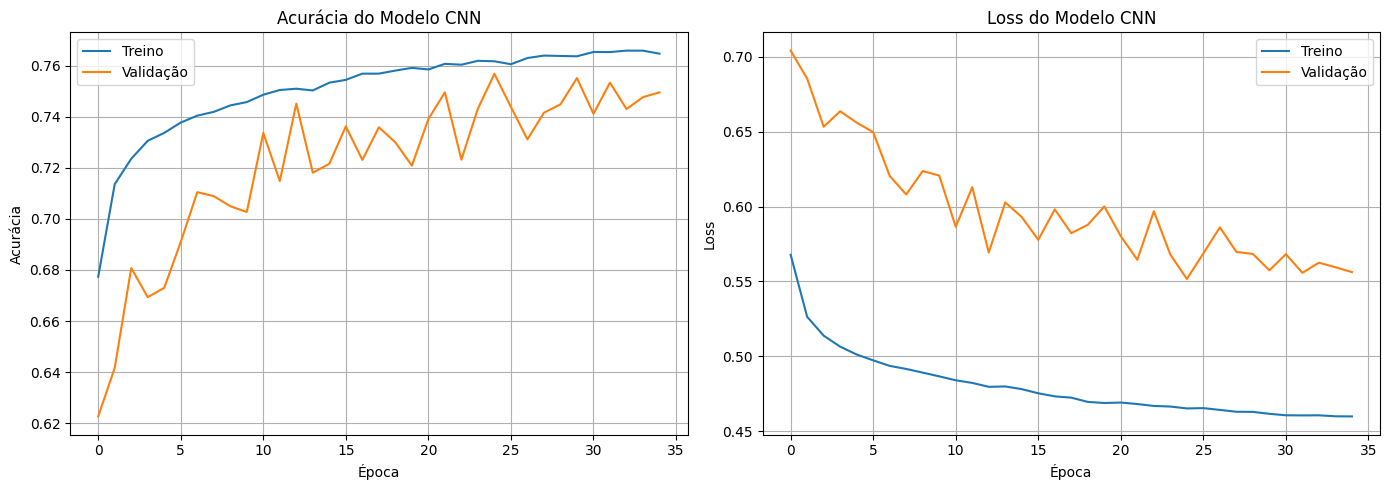

In [17]:
# Criar subplots lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === Acurácia ===
ax1.plot(history.history['accuracy'], label='Treino')
ax1.plot(history.history['val_accuracy'], label='Validação')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Acurácia do Modelo CNN')
ax1.legend()
ax1.grid(True)

# === Loss ===
ax2.plot(history.history['loss'], label='Treino')
ax2.plot(history.history['val_loss'], label='Validação')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Loss do Modelo CNN')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Avaliação Final do Modelo
 
Gera métricas de classificação no conjunto de teste, ajusta o threshold para melhor F1-score e exibe a matriz de confusão.

873/873 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step
Melhor threshold: 0.55 | F1: 0.399


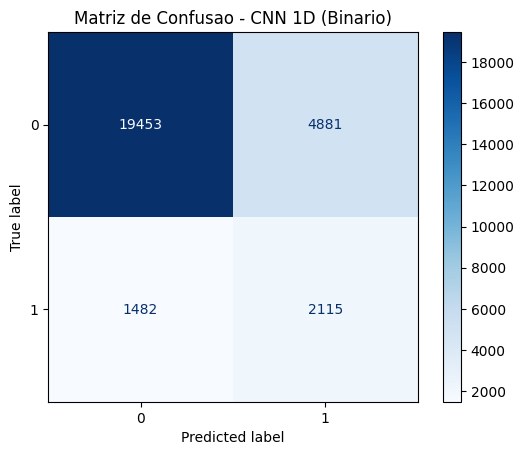


Acuracia final (treino):     76.46%
Acuracia final (validacao):  74.95%


In [18]:
# Avaliação final no conjunto de teste
y_prob = model.predict(X_test).ravel()

# Ajuste de limiar para maximizar F1 no conjunto de teste
thresholds = np.linspace(0.1, 0.9, 17)
best_threshold = 0.5
best_f1 = -1.0

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    tp = np.sum((y_test == 1) & (y_pred_thr == 1))
    fp = np.sum((y_test == 0) & (y_pred_thr == 1))
    fn = np.sum((y_test == 1) & (y_pred_thr == 0))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

print(f"Melhor threshold: {best_threshold:.2f} | F1: {best_f1:.3f}")

y_pred = (y_prob >= best_threshold).astype(int)

# Calcular e visualizar matriz de confusao
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusao - CNN 1D (Binario)")
plt.show()

# Exibir acuracias finais
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n{'='*50}")
print(f"Acuracia final (treino):     {final_train_acc*100:.2f}%")
print(f"Acuracia final (validacao):  {final_val_acc*100:.2f}%")
print(f"{'='*50}")

## 7. Exportação do Modelo Treinado
 
Salva o modelo treinado em formato Keras (.keras) para posterior conversão e uso embarcado.

In [19]:
# Criar diretório de saída
if not os.path.exists("../../models"):
    os.makedirs("../../models")

# Salvar modelo em formato Keras
model.save("../../models/model.keras")
print("✓ Modelo salvo: ../../models/model.keras")

✓ Modelo salvo: ../../models/model.keras


## 8. Conversão para TensorFlow Lite INT8
 
Converte o modelo salvo para o formato TFLite INT8, reduzindo tamanho e otimizando para execução em microcontroladores.

In [20]:
# Dataset representativo para calibracao da quantizacao
def rep_data_gen():
    """
    Fornece amostras representativas para o conversor TFLite calibrar
    os parametros de quantizacao (scale e zero_point).
    Usa amostras do conjunto de treino com o mesmo pre-processamento.
    IMPORTANTE: Retorna float32 explicitamente (TFLite nao aceita float64).
    """
    for i in range(200):
        yield [X_train[i:i+1].astype(np.float32)]

# Configurar conversor TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_data_gen

# Forcar quantizacao completa para INT8 (ideal para microcontroladores)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Gerar modelo quantizado
tflite_int8 = converter.convert()

# Salvar modelo TFLite
output_path = "../../models/model_int8.tflite"
with open(output_path, "wb") as f:
    f.write(tflite_int8)

print(f"✓ Modelo TFLite INT8 salvo: {output_path}")
print(f"✓ Tamanho: {len(tflite_int8):,} bytes (~{len(tflite_int8)/1024:.1f} KB)")

INFO:tensorflow:Assets written to: /tmp/tmphg7k19jb/assets


INFO:tensorflow:Assets written to: /tmp/tmphg7k19jb/assets


Saved artifact at '/tmp/tmphg7k19jb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138221452065872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452066448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452066256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452065680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452066064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220362810192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220362810000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138221452064720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220362809808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220362809424: Ten

/home/matheus/Documentos/Meus Codes/Embarcatech/tarefa30_IA5_embarcatech/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✓ Modelo TFLite INT8 salvo: ../../models/model_int8.tflite
✓ Tamanho: 47,536 bytes (~46.4 KB)


W0000 00:00:1770421989.335593  355285 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1770421989.335619  355285 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-06 20:53:09.336050: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphg7k19jb
2026-02-06 20:53:09.336721: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-06 20:53:09.336730: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmphg7k19jb
I0000 00:00:1770421989.344572  355285 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-02-06 20:53:09.345701: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-06 20:53:09.377473: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmphg7k19jb
2026-02-06 20:53:09.387047: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

## 9. Exportação do Modelo para C/C++
 
Gera um header C/C++ com o modelo TFLite em formato de array de bytes, pronto para ser incluído no firmware embarcado.

In [21]:
# Ler modelo binario
with open("../../models/model_int8.tflite", "rb") as f:
    data = f.read()

# Converter para hexadecimal
hexstr = binascii.hexlify(data).decode("ascii")

# Gerar header C/C++
output_path = "../../models/model_int8.h"
with open(output_path, "w") as f:
    f.write('#pragma once\n')
    f.write('#include <stdint.h>\n\n')
    f.write('// Modelo CNN 1D INT8 - Previsao de chuva\n')
    f.write('// Tamanho: {:,} bytes\n\n'.format(len(data)))
    f.write('alignas(16) const unsigned char model_int8_tflite[] = {\n')

    # Escrever 12 bytes por linha para legibilidade
    for i in range(0, len(hexstr), 2*12):
        chunk = hexstr[i:i+2*12]
        bytes_list = [f"0x{chunk[j:j+2]}" for j in range(0, len(chunk), 2)]
        f.write("  " + ", ".join(bytes_list) + ",\n")

    f.write("};\n\n")
    f.write(f"const unsigned int model_int8_tflite_len = {len(data)};\n")

print(f"✓ Header C gerado: {output_path}")
print(f"✓ Uso no codigo: #include \"model_int8.h\"")

✓ Header C gerado: ../../models/model_int8.h
✓ Uso no codigo: #include "model_int8.h"


## 10. Validação do Modelo Exportado em lote
 
Executa a inferência em todo o conjunto de teste já em memória, usando o modelo exportado, e calcula a acurácia e matriz de confusão.

In [22]:
# Carregar modelo exportado e inicializar interpretador
hex_bytes = []
with open("../../models/model_int8.h") as f:
    for line in f:
        if "0x" in line:
            parts = line.strip().split(",")
            for p in parts:
                p = p.strip()
                if p.startswith("0x"):
                    hex_bytes.append(int(p, 16))
tflite_model = bytes(hex_bytes)
print(f"✓ Modelo carregado do header: {len(tflite_model):,} bytes")

# Inicializar interpretador TFLite
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

✓ Modelo carregado do header: 47,536 bytes


/home/matheus/Documentos/Meus Codes/Embarcatech/tarefa30_IA5_embarcatech/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Acurácia do modelo exportado (TFLite) no teste: 74.56%


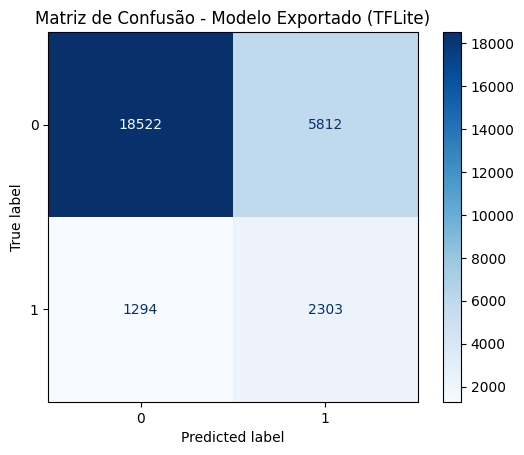

In [23]:
# Inferência em lote no conjunto de teste
in_scale, in_zp = input_details[0]["quantization"]
out_scale, out_zp = output_details[0]["quantization"]
X_test_q = np.round(X_test / in_scale + in_zp).astype(np.int8)

y_pred_exported = []
for i in range(X_test_q.shape[0]):
    interpreter.set_tensor(input_details[0]["index"], X_test_q[i:i+1])
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]["index"])[0]
    out_float = (out.astype(np.float32) - out_zp) * out_scale
    prob = float(out_float[0])
    y_pred_exported.append(int(prob >= 0.5))

y_pred_exported = np.array(y_pred_exported)

# Avaliar acurácia e matriz de confusão
acc = accuracy_score(y_test, y_pred_exported)
print(f"Acurácia do modelo exportado (TFLite) no teste: {acc*100:.2f}%")
cm = confusion_matrix(y_test, y_pred_exported)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Modelo Exportado (TFLite)")
plt.show()